In [31]:
import os
import glob
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, zscore
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

### Plots figure 1

In [32]:
import glob, os
os.chdir("/data/kumarr17/supplemetary_table_cyt_manuscript/")
cv_data_df=[] 
for i in glob.glob("*"+'.csv'):
    cv_data_df.append(i)
os.chdir("/data/kumarr17/supplemetary_table_cyt_manuscript/") 

In [34]:
list_df=[]
for i in range(12):
    cv_df=pd.read_csv("/data/kumarr17/supplemetary_table_cyt_manuscript/"+cv_data_df[i],index_col='Unnamed: 0')
    cv_df.columns=[cv_data_df[i].split('_')[0]]
    list_df.append(cv_df)
df=pd.concat(list_df,axis=1,join="inner").T

#### Figure 1A

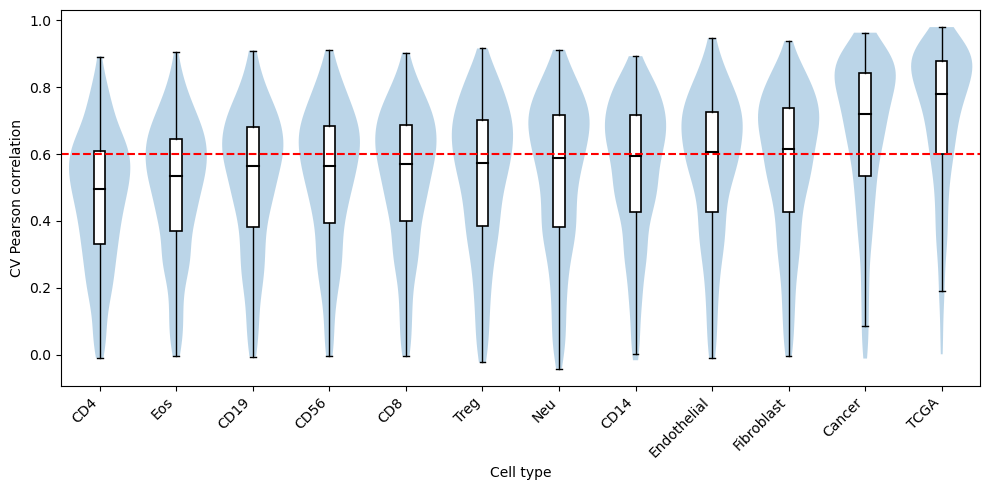

In [35]:
# --------------------------------------------------
# Calculate median across cytokines for each cell type
# --------------------------------------------------

medians = df.median(axis=1)

# Sort cell types from lowest to highest median
order = medians.sort_values(ascending=True).index

# Reorder dataframe
df_sorted = df.loc[order]


# --------------------------------------------------
# Prepare data
# --------------------------------------------------

data = [
    df_sorted.loc[cell].dropna().values
    for cell in df_sorted.index
]

positions = np.arange(1, len(df_sorted.index) + 1)


# --------------------------------------------------
# Violin + internal boxplot
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

# Violin plot
ax.violinplot(
    data,
    positions=positions,
    widths=0.8,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

# Internal boxplot
ax.boxplot(
    data,
    positions=positions,
    widths=0.15,
    showfliers=False,
    patch_artist=True,
    boxprops=dict(
        facecolor='white',
        edgecolor='black',
        linewidth=1.2
    ),
    medianprops=dict(
        color='black',
        linewidth=1.5
    ),
    whiskerprops=dict(
        color='black',
        linewidth=1
    ),
    capprops=dict(
        color='black',
        linewidth=1
    )
)


# --------------------------------------------------
# Labels
# --------------------------------------------------

ax.set_xticks(positions)
ax.set_xticklabels(
    df_sorted.index,
    rotation=45,
    ha='right'
)

ax.set_ylabel("CV Pearson correlation")
ax.set_xlabel("Cell type")

# Remove grid
ax.grid(False)


# --------------------------------------------------
# Reference line at 0.4
# --------------------------------------------------

ax.axhline(
    y=0.6,
    color='red',
    linestyle='--',
    linewidth=1.5
)


# --------------------------------------------------
# Save for manuscript
# --------------------------------------------------

plt.tight_layout()

plt.savefig(
    "/data/kumarr17/cytokine_figure_directory/celltype_CV_violin_boxplot_0.6.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

#### Figure 1B

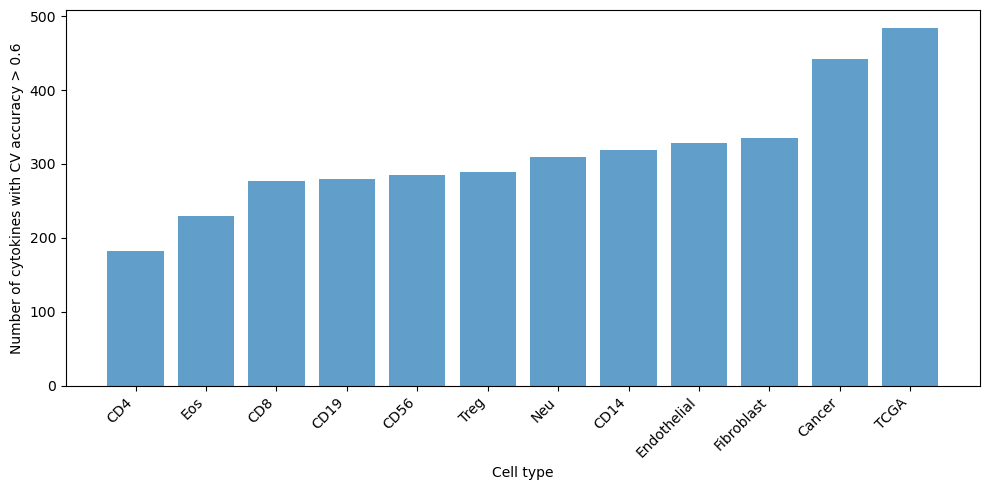

In [36]:
df_tr=df.T
# Count cytokines with CV accuracy > 0.6
count_above_04 = (df_tr > 0.6).sum(axis=0)

# Sort from lowest to highest
count_above_04 = count_above_04.sort_values(ascending=True)

# --------------------------------------------------
# Plot
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    count_above_04.index,
    count_above_04.values,
    alpha=0.7
)

# Labels
ax.set_xlabel("Cell type")
ax.set_ylabel("Number of cytokines with CV accuracy > 0.6")

ax.tick_params(axis='x', rotation=45)

for label in ax.get_xticklabels():
    label.set_ha('right')

# Remove grid
ax.grid(False)

# Transparent background
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

plt.tight_layout()

# --------------------------------------------------
# Save as transparent SVG
# --------------------------------------------------

#plt.savefig(
#    "/data/kumarr17/cytokine_figure_directory/cytokines_CV_above_0.6_barplot.svg",
#    format="svg",
#    transparent=True,
#    bbox_inches="tight"
#)

plt.show()